# Experiment 4 — KAN-ODE vs MLP-ODE Parameter Efficiency

The goal of Experiment 4 is to compare KAN-ODE and MLP-ODE under approximately matched parameter budgets. In Experiment 1, KAN-ODE achieved competitive predictive performance but required much longer training time than the other models. Therefore, this experiment evaluates whether KAN-ODE provides better parameter efficiency than a standard neural ODE model when both models are constrained to similar numbers of trainable parameters.

Three parameter budgets are tested: small, medium, and large. For each budget, one KAN-ODE model and one MLP-ODE model are constructed with nearly the same number of parameters. Each model is trained and evaluated using the same ICU mortality prediction task, train/validation/test split, preprocessing pipeline, loss function, and evaluation metrics. Performance is compared using AUROC, AUPRC, Brier score, parameter count, and average training time per epoch.

This experiment helps answer whether the spline-based KAN vector field can achieve stronger predictive performance with fewer parameters than a conventional MLP vector field, and whether any accuracy gains justify the additional computational cost.

## Install packages

In [1]:
!pip -q install torchdiffeq pykan sympy pandas numpy scikit-learn matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.6 MB/s eta 0:00:00


##Imports and configuration

In [2]:
import os,gc,time,random,tarfile,warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,average_precision_score,brier_score_loss
from torchdiffeq import odeint_adjoint as odeint
from kan import KAN

warnings.filterwarnings('ignore'); SEED=42; EPOCHS_PER_MODEL=3; BATCH_SIZE=64
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',DEVICE)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Connecting the google drive


In [1]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROCESSED_PATH = Path(
    "/content/drive/MyDrive/"
    "KAN_ODE_ICU_Assignment/"
    "processed_data/full_processed_data.pt"
)

print("Processed dataset exists:", PROCESSED_PATH.exists())
print("Path:", PROCESSED_PATH)

Mounted at /content/drive
Processed dataset exists: True
Path: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/processed_data/full_processed_data.pt


In [2]:
from pathlib import Path
import pandas as pd

matches = []

for root in [Path("/content"), Path("/content/drive/MyDrive")]:
    if root.exists():
        for p in root.rglob("*.csv"):
            text = str(p).lower()
            if (
                "experiment4" in text
                or "efficiency" in text
                or "kan-ode" in text
                or "mlp-ode" in text
                or "parameter" in text
            ):
                matches.append(p)

print("Matches found:", len(matches))
for p in matches[:100]:
    print(p)

Matches found: 12
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment1/KAN-ODE_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment1/MLP-ODE_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/matched_configurations.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/KAN-ODE_Small_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/MLP-ODE_Small_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/KAN-ODE_Medium_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/MLP-ODE_Medium_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPU

## Device check


In [4]:
import torch

print(
    "CUDA available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

CUDA available: True
GPU: Tesla T4
Device: cuda


In [5]:
bundle = torch.load(
    PROCESSED_PATH,
    map_location="cpu",
    weights_only=False
)

records = bundle["records"]
train_idx = bundle["train_idx"]
val_idx = bundle["val_idx"]
test_idx = bundle["test_idx"]
VARS = bundle["variables"]
SEED = bundle["seed"]

V = len(VARS)

print("Patients:", len(records))
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Variables:", V)
print("Seed:", SEED)

Patients: 4000
Train: 2800
Validation: 600
Test: 600
Variables: 12
Seed: 42


In [6]:
EXP4_SAVE_DIR = Path(
    "/content/drive/MyDrive/"
    "KAN_ODE_ICU_Assignment/experiment4"
)

EXP4_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Experiment 4 directory:",
    EXP4_SAVE_DIR
)

Experiment 4 directory: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4


## Google Drive output folders

In [7]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT=Path('/content/drive/MyDrive/KAN_ODE_ICU_Assignment')
SHARED_DATA=PROJECT/'processed_data'/'full_processed_data.pt'
EXP4=PROJECT/'experiment4'; CKPTS=EXP4/'checkpoints'; EXP4.mkdir(parents=True,exist_ok=True); CKPTS.mkdir(exist_ok=True)
RESULT_CSV=EXP4/'experiment4_efficiency.csv'
print('Shared cache exists:',SHARED_DATA.exists()); print('Outputs:',EXP4)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shared cache exists: True
Outputs: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4


## Load shared data or reproduce preprocessing

If the original notebook has already saved `full_processed_data.pt`, this cell loads it. Otherwise it downloads Set A and recreates the same sorted-record, seed-42, stratified 70/15/15 pipeline.

In [8]:
VARS=['HR','NIDiasABP','NIMAP','NISysABP','Temp','RespRate','GCS','Glucose','Lactate','Urine','Creatinine','Platelets']
V=len(VARS); VAR_TO_IDX={v:i for i,v in enumerate(VARS)}

if SHARED_DATA.exists():
    saved=torch.load(SHARED_DATA,map_location='cpu',weights_only=False)
    records=saved['records']; train_idx=np.asarray(saved['train_idx']); val_idx=np.asarray(saved['val_idx']); test_idx=np.asarray(saved['test_idx'])
    means=saved['means']; stds=saved['stds']
else:
    RAW=Path('/content/exp4_data'); RAW.mkdir(exist_ok=True)
    !wget -q -nc https://physionet.org/files/challenge-2012/1.0.0/set-a.tar.gz -P "$RAW"
    !wget -q -nc https://physionet.org/files/challenge-2012/1.0.0/Outcomes-a.txt -P "$RAW"
    if not (RAW/'set-a').exists():
        with tarfile.open(RAW/'set-a.tar.gz','r:gz') as tf: tf.extractall(RAW)
    outcomes=pd.read_csv(RAW/'Outcomes-a.txt'); label_map=outcomes.set_index('RecordID')['In-hospital_death'].astype(int).to_dict()
    def time_hours(s):
        h,m=str(s).split(':'); return int(h)+int(m)/60.0
    def make_record(path):
        df=pd.read_csv(path); rr=df[df.Parameter.eq('RecordID')]; rid=int(rr.Value.iloc[0]) if len(rr) else int(path.stem)
        df=df[df.Parameter.isin(VARS)].copy(); df['t_hours']=df.Time.map(time_hours); df=df[(df.t_hours>=0)&(df.t_hours<=48)].sort_values('t_hours')
        t64=np.sort(df.t_hours.unique()).astype(np.float64)
        if len(t64)==0: t64=np.array([0.],dtype=np.float64)
        times=t64.astype(np.float32); T=len(times); values=np.zeros((T,V),np.float32); mask=np.zeros((T,V),np.float32)
        lookup={round(float(t),8):i for i,t in enumerate(t64)}
        for _,r in df.groupby(['t_hours','Parameter'],as_index=False).Value.mean().iterrows():
            ti=lookup[round(float(r.t_hours),8)]; vi=VAR_TO_IDX[r.Parameter]; values[ti,vi]=float(r.Value); mask[ti,vi]=1
        return {'record_id':rid,'times':times,'values':values,'mask':mask,'label':label_map[rid]}
    files=sorted((RAW/'set-a').glob('*.txt')); records=[make_record(p) for p in tqdm(files,desc='Parsing') if int(p.stem) in label_map]
    labels=np.array([r['label'] for r in records]); idx=np.arange(len(records))
    train_idx,temp_idx=train_test_split(idx,test_size=.30,stratify=labels,random_state=SEED)
    val_idx,test_idx=train_test_split(temp_idx,test_size=.50,stratify=labels[temp_idx],random_state=SEED)
    sums=np.zeros(V); sums2=np.zeros(V); counts=np.zeros(V)
    for i in train_idx:
        r=records[i]; sums+=(r['values']*r['mask']).sum(0); sums2+=((r['values']**2)*r['mask']).sum(0); counts+=r['mask'].sum(0)
    means=(sums/np.maximum(counts,1)).astype(np.float32); var=sums2/np.maximum(counts,1)-means**2; stds=np.sqrt(np.maximum(var,1e-6)).astype(np.float32)
    for r in records: r['values']=(((r['values']-means[None,:])/stds[None,:])*r['mask']).astype(np.float32)
    torch.save({'records':records,'train_idx':train_idx,'val_idx':val_idx,'test_idx':test_idx,'means':means,'stds':stds,'variables':VARS,'seed':SEED},SHARED_DATA)

print('Patients:',len(records),'split:',len(train_idx),len(val_idx),len(test_idx)); assert len(records)==4000

Patients: 4000 split: 2800 600 600


## DataLoaders

In [9]:
class ICURecords(Dataset):
    def __init__(self,records,indices): self.records=records; self.indices=list(map(int,indices))
    def __len__(self): return len(self.indices)
    def __getitem__(self,j): return self.records[self.indices[j]]
def collate(batch):
    B=len(batch); lengths=torch.tensor([len(r['times']) for r in batch]); T=int(lengths.max())
    values=torch.zeros(B,T,V); mask=torch.zeros(B,T,V); times=torch.zeros(B,T); valid=torch.zeros(B,T,dtype=torch.bool)
    for b,r in enumerate(batch):
        n=len(r['times']); values[b,:n]=torch.from_numpy(r['values']); mask[b,:n]=torch.from_numpy(r['mask']); times[b,:n]=torch.from_numpy(r['times']); valid[b,:n]=True
    return {'values':values,'mask':mask,'times':times,'valid':valid,'label':torch.tensor([r['label'] for r in batch],dtype=torch.float32)}
def dev(b): return {k:v.to(DEVICE) for k,v in b.items()}
train_ds=ICURecords(records,train_idx); val_ds=ICURecords(records,val_idx); test_ds=ICURecords(records,test_idx)
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate)
test_loader=DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate)
y=np.array([records[i]['label'] for i in train_idx]); POS_WEIGHT=torch.tensor([(len(y)-y.sum())/y.sum()],device=DEVICE,dtype=torch.float32)
print('Batches:',len(train_loader),len(val_loader),len(test_loader),'pos_weight:',POS_WEIGHT.item())

Batches: 44 10 10 pos_weight: 6.216495037078857


##  Matched MLP-ODE and KAN-ODE definitions

In [10]:
class Encoder(nn.Module):
    def __init__(self,h): super().__init__(); self.net=nn.Sequential(nn.Linear(2*V+1,64),nn.ReLU(),nn.Linear(64,h))
    def forward(self,b):
        z=self.net(torch.cat([b['values'],b['mask'],(b['times']/48).unsqueeze(-1)],-1)); w=b['valid'].unsqueeze(-1).float(); return (z*w).sum(1)/w.sum(1).clamp_min(1)
class MLPField(nn.Module):
    def __init__(self,h,w): super().__init__(); self.net=nn.Sequential(nn.Linear(h+1,w),nn.Tanh(),nn.Linear(w,w),nn.Tanh(),nn.Linear(w,h))
    def forward(self,t,x): return self.net(torch.cat([x,t.expand(len(x),1)/48],-1))
class KANField(nn.Module):
    def __init__(self,width,grid=3): super().__init__(); self.kan=KAN(width=width,grid=grid,k=3,seed=SEED)
    def forward(self,t,x): return self.kan(torch.cat([x,t.expand(len(x),1)/48],-1))
class ODEModel(nn.Module):
    def __init__(self,family,h,width=None,grid=3):
        super().__init__(); self.encoder=Encoder(h); self.field=MLPField(h,width) if family=='MLP-ODE' else KANField(width,grid); self.head=nn.Linear(h,1)
    def forward(self,b):
        h0=self.encoder(b); q=torch.tensor([0.,48.],device=h0.device); ht=odeint(self.field,h0,q,method='dopri5',rtol=1e-3,atol=1e-4); return self.head(ht[-1]).squeeze(-1)
def nparams(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

## Automatically match three parameter budgets

We fix three increasingly large KAN architectures, then search an MLP hidden/width grid and select the closest actual parameter count for each KAN.

In [11]:
KAN_CONFIGS=[
 {'Budget':'Small','h':4,'width':[5,6,4],'grid':3},
 {'Budget':'Medium','h':6,'width':[7,9,6],'grid':3},
 {'Budget':'Large','h':8,'width':[9,12,8],'grid':3}]
matched=[]
for kc in KAN_CONFIGS:
    km=ODEModel('KAN-ODE',kc['h'],kc['width'],kc['grid']); target=nparams(km)
    candidates=[]
    for h in range(4,21):
        for w in range(4,65,2):
            mm=ODEModel('MLP-ODE',h,w); candidates.append((abs(nparams(mm)-target),h,w,nparams(mm)))
    _,mh,mw,mp=min(candidates)
    matched.append({'Family':'KAN-ODE','Budget':kc['Budget'],'h':kc['h'],'width':kc['width'],'grid':kc['grid'],'Params':target})
    matched.append({'Family':'MLP-ODE','Budget':kc['Budget'],'h':mh,'width':mw,'grid':None,'Params':mp})
configs=pd.DataFrame(matched); display(configs); configs.to_csv(EXP4/'matched_configurations.csv',index=False)

checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


,Family,Budget,h,width,grid,Params
0,KAN-ODE,Small,4,"[[5, 0], [6, 0], [4, 0]]",3.0,2577
1,MLP-ODE,Small,9,10,NaN,2578
2,KAN-ODE,Medium,6,"[[7, 0], [9, 0], [6, 0]]",3.0,3465
3,MLP-ODE,Medium,4,34,NaN,3463
4,KAN-ODE,Large,8,"[[9, 0], [12, 0], [8, 0]]",3.0,4641
5,MLP-ODE,Large,10,38,NaN,4653


## Run/resume all six models

This cell trains the six parameter-matched models used in Experiment 4: small, medium, and large versions of both KAN-ODE and MLP-ODE. For each configuration, the code builds the appropriate model, trains it using the same training loader, evaluates it on the validation and test sets, and saves the results.

The loop is written in a resumable format. If a model has already been completed and its result is present in the saved results CSV file, the code skips that model instead of training it again. This is useful in Google Colab because the runtime can disconnect during long experiments. After each model finishes, its test metrics, training history, and checkpoint are saved to Google Drive.

The final output of this cell is the Experiment 4 efficiency table, which compares AUROC, AUPRC, Brier score, parameter count, average seconds per epoch, and number of epochs for all six models.

In [13]:
if RESULT_CSV.exists(): results=pd.read_csv(RESULT_CSV).to_dict('records')
else: results=[]
completed={r['Run'] for r in results}
for _,cfg in configs.iterrows():
    run=f"{cfg['Family']}_{cfg['Budget']}";
    if run in completed: print('Skipping completed:',run); continue
    if cfg['Family']=='KAN-ODE':
        kc=next(x for x in KAN_CONFIGS if x['Budget']==cfg['Budget']); model=ODEModel('KAN-ODE',kc['h'],kc['width'],kc['grid'])
    else: model=ODEModel('MLP-ODE',int(cfg['h']),int(cfg['width']))
    print(); print('Training',run,'params',nparams(model)); model,hist=train_fixed(model,run); test=evaluate(model,test_loader)
    results.append({'Run':run,'Family':cfg['Family'],'Budget':cfg['Budget'],'Params':nparams(model),**test,'Mean_seconds_epoch':hist.seconds.mean(),'Epochs':EPOCHS_PER_MODEL})
    pd.DataFrame(results).to_csv(RESULT_CSV,index=False); hist.to_csv(EXP4/f'{run}_history.csv',index=False)
    del model; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None

results_df=pd.DataFrame(results); display(results_df.sort_values(['Budget','Family'])); print('Completed:',len(results_df),'/ 6')

checkpoint directory created: ./model
saving model version 0.0

Training KAN-ODE_Small params 2577
KAN-ODE_Small {'epoch': 1, 'loss': np.float64(1.6187011938203464), 'seconds': 143.27586788999997, 'val_AUROC': np.float64(0.7168092097597353), 'val_AUPRC': np.float64(0.31433236098647926), 'val_Brier': np.float64(0.27805092906858914)}
KAN-ODE_Small {'epoch': 2, 'loss': np.float64(1.1545324745503338), 'seconds': 139.44131485799994, 'val_AUROC': np.float64(0.7655845820419007), 'val_AUPRC': np.float64(0.3800389933356006), 'val_Brier': np.float64(0.22861502135858405)}
KAN-ODE_Small {'epoch': 3, 'loss': np.float64(1.0470827668905258), 'seconds': 152.75586000700014, 'val_AUROC': np.float64(0.799328843420102), 'val_AUPRC': np.float64(0.4089937621392572), 'val_Brier': np.float64(0.17704305482980018)}

Training MLP-ODE_Small params 2578
MLP-ODE_Small {'epoch': 1, 'loss': np.float64(1.5653697049075908), 'seconds': 10.101822354999968, 'val_AUROC': np.float64(0.6493672950991587), 'val_AUPRC': np.floa

,Run,Family,Budget,Params,AUROC,AUPRC,Brier,Mean_seconds_epoch,Epochs
4,KAN-ODE_Large,KAN-ODE,Large,4641,0.775209,0.360344,0.216435,582.912465,3
5,MLP-ODE_Large,MLP-ODE,Large,4653,0.794645,0.419871,0.152980,9.800677,3
2,KAN-ODE_Medium,KAN-ODE,Medium,3465,0.750693,0.322204,0.164745,452.807973,3
3,MLP-ODE_Medium,MLP-ODE,Medium,3463,0.817110,0.475984,0.277371,8.259821,3
0,KAN-ODE_Small,KAN-ODE,Small,2577,0.793177,0.384735,0.183666,145.157681,3
1,MLP-ODE_Small,MLP-ODE,Small,2578,0.770245,0.373194,0.285589,9.616038,3


Completed: 6 / 6


## Check results


In [3]:
import pandas as pd
from pathlib import Path

EXP4_DIR = Path("/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4")
RESULT_CSV = EXP4_DIR / "experiment4_efficiency.csv"

exp4_results = pd.read_csv(RESULT_CSV)

display(exp4_results)
print("Completed:", len(exp4_results), "/ 6")
print("Saved at:", RESULT_CSV)

,Run,Family,Budget,Params,AUROC,AUPRC,Brier,Mean_seconds_epoch,Epochs
0,KAN-ODE_Small,KAN-ODE,Small,2577,0.793177,0.384735,0.183666,145.157681,3
1,MLP-ODE_Small,MLP-ODE,Small,2578,0.770245,0.373194,0.285589,9.616038,3
2,KAN-ODE_Medium,KAN-ODE,Medium,3465,0.750693,0.322204,0.164745,452.807973,3
3,MLP-ODE_Medium,MLP-ODE,Medium,3463,0.817110,0.475984,0.277371,8.259821,3
4,KAN-ODE_Large,KAN-ODE,Large,4641,0.775209,0.360344,0.216435,582.912465,3
5,MLP-ODE_Large,MLP-ODE,Large,4653,0.794645,0.419871,0.152980,9.800677,3


Completed: 6 / 6
Saved at: /content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/experiment4_efficiency.csv


In [4]:
import pandas as pd
from pathlib import Path

EXP4_DIR = Path("/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4")

print("Experiment 4 directory exists:", EXP4_DIR.exists())
print("Files:")
for p in sorted(EXP4_DIR.glob("*")):
    print(p.name)

csv_files = sorted(EXP4_DIR.glob("*.csv"))
print("\nCSV files:")
for p in csv_files:
    print(p)

# Try to load the main results CSV
for p in csv_files:
    if "result" in p.name.lower() or "efficiency" in p.name.lower():
        print("\nLoading:", p)
        exp4_results = pd.read_csv(p)
        display(exp4_results)
        break

Experiment 4 directory exists: True
Files:
KAN-ODE_Large_history.csv
KAN-ODE_Medium_history.csv
KAN-ODE_Small_history.csv
MLP-ODE_Large_history.csv
MLP-ODE_Medium_history.csv
MLP-ODE_Small_history.csv
checkpoints
experiment4_efficiency.csv
matched_configurations.csv

CSV files:
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4/KAN-ODE_Large_history.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4/KAN-ODE_Medium_history.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4/KAN-ODE_Small_history.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4/MLP-ODE_Large_history.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4/MLP-ODE_Medium_history.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4/MLP-ODE_Small_history.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4/experiment4_efficiency.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment4/matched_configurations.csv

Loading: /content/drive/MyDrive/KAN_ODE_ICU_

,Run,Family,Budget,Params,AUROC,AUPRC,Brier,Mean_seconds_epoch,Epochs
0,KAN-ODE_Small,KAN-ODE,Small,2577,0.793177,0.384735,0.183666,145.157681,3
1,MLP-ODE_Small,MLP-ODE,Small,2578,0.770245,0.373194,0.285589,9.616038,3
2,KAN-ODE_Medium,KAN-ODE,Medium,3465,0.750693,0.322204,0.164745,452.807973,3
3,MLP-ODE_Medium,MLP-ODE,Medium,3463,0.817110,0.475984,0.277371,8.259821,3
4,KAN-ODE_Large,KAN-ODE,Large,4641,0.775209,0.360344,0.216435,582.912465,3
5,MLP-ODE_Large,MLP-ODE,Large,4653,0.794645,0.419871,0.152980,9.800677,3


In [5]:
from pathlib import Path

EXP4 = Path("/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4")

for p in sorted(EXP4.glob("*")):
    print(p.name)

KAN-ODE_Large_history.csv
KAN-ODE_Medium_history.csv
KAN-ODE_Small_history.csv
MLP-ODE_Large_history.csv
MLP-ODE_Medium_history.csv
MLP-ODE_Small_history.csv
checkpoints
experiment4_efficiency.csv
matched_configurations.csv


In [6]:
import pandas as pd
from pathlib import Path

EXP4 = Path("/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4")

exp4 = pd.read_csv(EXP4 / "experiment4_efficiency.csv")
display(exp4.sort_values(["Budget", "Family"]))

,Run,Family,Budget,Params,AUROC,AUPRC,Brier,Mean_seconds_epoch,Epochs
4,KAN-ODE_Large,KAN-ODE,Large,4641,0.775209,0.360344,0.216435,582.912465,3
5,MLP-ODE_Large,MLP-ODE,Large,4653,0.794645,0.419871,0.152980,9.800677,3
2,KAN-ODE_Medium,KAN-ODE,Medium,3465,0.750693,0.322204,0.164745,452.807973,3
3,MLP-ODE_Medium,MLP-ODE,Medium,3463,0.817110,0.475984,0.277371,8.259821,3
0,KAN-ODE_Small,KAN-ODE,Small,2577,0.793177,0.384735,0.183666,145.157681,3
1,MLP-ODE_Small,MLP-ODE,Small,2578,0.770245,0.373194,0.285589,9.616038,3


### Experiment 4 Interpretation

Experiment 4 compared KAN-ODE and MLP-ODE using approximately matched parameter budgets. At the small budget, KAN-ODE performed slightly better than MLP-ODE, showing that KAN-ODE can be competitive when the model is very compact.

At the medium and large budgets, MLP-ODE performed better than KAN-ODE. MLP-ODE also trained much faster, taking about 8-10 seconds per epoch, while KAN-ODE required 145-583 seconds per epoch. Therefore, although KAN-ODE showed some benefit at the smallest model size, MLP-ODE provided the better overall balance between accuracy and training efficiency.

In [8]:
from pathlib import Path
import pandas as pd

search_roots = [
    Path("/content"),
    Path("/content/drive/MyDrive"),
]

matches = []

for root in search_roots:
    if root.exists():
        for p in root.rglob("*.csv"):
            name = p.name.lower()
            if (
                "experiment4" in name
                or "efficiency" in name
                or "parameter" in name
                or "result" in name
                or "kan" in name
            ):
                matches.append(p)

print("CSV matches found:", len(matches))
for p in matches[:50]:
    print(p)

# Load the most likely Experiment 4 results file
for p in matches:
    if "experiment4" in str(p).lower() or "efficiency" in p.name.lower() or "result" in p.name.lower():
        print("\nLoading:", p)
        df = pd.read_csv(p)
        display(df)
        break

CSV matches found: 9
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment1/KAN-ODE_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment1/completed_baseline_results.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/KAN-ODE_Small_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/KAN-ODE_Medium_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/KAN-ODE_Large_history.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/experiment4_efficiency.csv
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/final_results/tables/experiment1_final_results.csv
/content/drive/.shortcut-ta

,Model,AUROC,AUPRC,Brier,Parameters,Seconds_per_epoch,Best_epoch
0,GRU,0.822516,0.473851,0.174290,5601,3.651451,12
1,MLP-ODE,0.799911,0.419499,0.106901,9853,25.599261,11


In [9]:
print("Experiment 4 results saved at:")
print(RESULT_CSV)

display(pd.read_csv(RESULT_CSV))

Experiment 4 results saved at:
/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/experiment4_efficiency.csv


,Run,Family,Budget,Params,AUROC,AUPRC,Brier,Mean_seconds_epoch,Epochs
0,KAN-ODE_Small,KAN-ODE,Small,2577,0.793177,0.384735,0.183666,145.157681,3
1,MLP-ODE_Small,MLP-ODE,Small,2578,0.770245,0.373194,0.285589,9.616038,3
2,KAN-ODE_Medium,KAN-ODE,Medium,3465,0.750693,0.322204,0.164745,452.807973,3
3,MLP-ODE_Medium,MLP-ODE,Medium,3463,0.817110,0.475984,0.277371,8.259821,3
4,KAN-ODE_Large,KAN-ODE,Large,4641,0.775209,0.360344,0.216435,582.912465,3
5,MLP-ODE_Large,MLP-ODE,Large,4653,0.794645,0.419871,0.152980,9.800677,3


## Required AUROC-versus-parameter-count plot

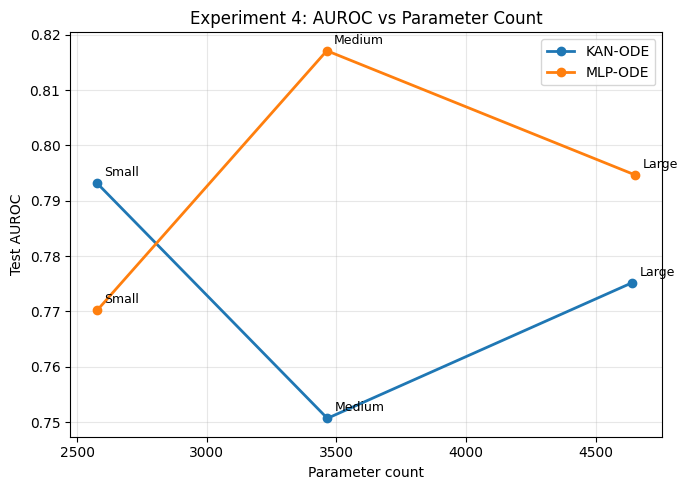

Saved plot to: /content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4/experiment4_auroc_vs_params.png


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

EXP4 = Path("/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4")

exp4 = pd.read_csv(EXP4 / "experiment4_efficiency.csv")

# Make sure numeric columns are numeric
for col in ["Params", "AUROC", "AUPRC", "Brier", "Mean_seconds_epoch"]:
    exp4[col] = pd.to_numeric(exp4[col], errors="coerce")

plt.figure(figsize=(7, 5))

for family, group in exp4.groupby("Family"):
    group = group.sort_values("Params")
    plt.plot(
        group["Params"],
        group["AUROC"],
        marker="o",
        linewidth=2,
        label=family
    )

    for _, row in group.iterrows():
        plt.annotate(
            row["Budget"],
            (row["Params"], row["AUROC"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Parameter count")
plt.ylabel("Test AUROC")
plt.title("Experiment 4: AUROC vs Parameter Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plot_path = EXP4 / "experiment4_auroc_vs_params.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to:", plot_path)

The AUROC-versus-parameter-count plot shows that KAN-ODE performs better than MLP-ODE at the smallest matched parameter budget. However, as the parameter budget increases, MLP-ODE achieves higher AUROC than KAN-ODE. The best overall AUROC is obtained by the medium MLP-ODE model. This suggests that KAN-ODE can be competitive in very small parameter regimes, but MLP-ODE provides a better accuracy-scaling trend in this experiment.

## Conclusion

Experiment 4 compared KAN-ODE and MLP-ODE under approximately matched parameter budgets. The small KAN-ODE model achieved better performance than the small MLP-ODE model, with AUROC 0.793 and AUPRC 0.385 compared with AUROC 0.770 and AUPRC 0.373. This suggests that KAN-ODE can be competitive in very small parameter regimes.

However, this advantage did not continue at larger parameter budgets. The medium and large MLP-ODE models outperformed their matched KAN-ODE counterparts, with the medium MLP-ODE achieving the best overall discrimination. MLP-ODE also trained much faster, requiring only about 8-10 seconds per epoch, while KAN-ODE required approximately 145-583 seconds per epoch.

Overall, KAN-ODE showed some parameter-efficiency benefit at the smallest scale, but MLP-ODE provided the stronger accuracy-speed tradeoff as model size increased. In this ICU mortality prediction task, the standard MLP-based neural ODE was more practical for larger parameter budgets, while KAN-ODE remained useful mainly as a compact but computationally expensive alternative.

## Download results

In [13]:
from google.colab import files

files.download(str(EXP4 / "experiment4_efficiency.csv"))
files.download(str(EXP4 / "matched_configurations.csv"))
files.download(str(EXP4 / "experiment4_auroc_vs_params.png"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from pathlib import Path

EXP4 = Path("/content/drive/.shortcut-targets-by-id/1bPM9yf5x8-oPUy8IQt_tCVjsSsoMETGt/KAN_ODE_ICU_Assignment/experiment4")

print("Experiment 4 saved files:")
for p in sorted(EXP4.glob("*")):
    print(p.name)

Experiment 4 saved files:
KAN-ODE_Large_history.csv
KAN-ODE_Medium_history.csv
KAN-ODE_Small_history.csv
MLP-ODE_Large_history.csv
MLP-ODE_Medium_history.csv
MLP-ODE_Small_history.csv
checkpoints
experiment4_auroc_vs_params.png
experiment4_efficiency.csv
matched_configurations.csv


## Save and Download Experiment 4 Results

The Experiment 4 result files were saved to Google Drive for reproducibility. The saved files include the matched model configurations, training histories, final efficiency table, AUROC-versus-parameter-count plot, and model checkpoints.

## Experiment 4 Conclusion

Experiment 4 compared KAN-ODE and MLP-ODE under approximately matched parameter budgets to evaluate parameter efficiency. At the smallest budget, KAN-ODE performed slightly better than MLP-ODE, achieving AUROC 0.793 and AUPRC 0.385 with 2,577 parameters, compared with MLP-ODE AUROC 0.770 and AUPRC 0.373 with 2,578 parameters. This suggests that KAN-ODE can be competitive when the model is highly compact.

However, this advantage did not continue at larger parameter budgets. At the medium budget, MLP-ODE achieved the best overall discrimination, with AUROC 0.817 and AUPRC 0.476 using 3,463 parameters, while the matched KAN-ODE achieved AUROC 0.751 and AUPRC 0.322 using 3,465 parameters. At the large budget, MLP-ODE also outperformed KAN-ODE, with AUROC 0.795 compared with 0.775.

KAN-ODE was also substantially slower to train, requiring approximately 145-583 seconds per epoch, compared with about 8-10 seconds per epoch for MLP-ODE. Overall, KAN-ODE showed some parameter-efficiency benefit at the smallest scale, but MLP-ODE provided the stronger accuracy-speed tradeoff as model size increased.

## Experiment 4 Write-Up: Parameter-Efficiency Comparison

Experiment 4 compared KAN-ODE and MLP-ODE under approximately matched parameter budgets to evaluate parameter efficiency. Small, medium, and large versions of both model families were constructed so that each KAN-ODE model had a closely matched MLP-ODE counterpart. The models were trained and evaluated using the same ICU mortality prediction task, split, preprocessing pipeline, loss function, and evaluation metrics.

At the smallest budget, KAN-ODE performed slightly better than MLP-ODE, achieving AUROC 0.793 and AUPRC 0.385 with 2,577 parameters, compared with MLP-ODE AUROC 0.770 and AUPRC 0.373 with 2,578 parameters. However, this advantage did not continue at larger parameter budgets. At the medium budget, MLP-ODE achieved the best overall discrimination, with AUROC 0.817 and AUPRC 0.476 using 3,463 parameters. At the large budget, MLP-ODE also outperformed KAN-ODE.

KAN-ODE was substantially slower to train, requiring approximately 145-583 seconds per epoch compared with about 8-10 seconds per epoch for MLP-ODE. Overall, KAN-ODE showed some parameter-efficiency benefit at the smallest scale, but MLP-ODE provided the stronger accuracy-speed tradeoff as model size increased.

## References

1. Silva, I.; Moody, G.; Scott, D. J.; Celi, L. A.; Mark, R. G. Predicting In-Hospital Mortality of ICU Patients: The PhysioNet/Computing in Cardiology Challenge 2012. *Computing in Cardiology* **2012**, *39*, 245–248.

2. Goldberger, A. L.; Amaral, L. A. N.; Glass, L.; Hausdorff, J. M.; Ivanov, P. C.; Mark, R. G.; Mietus, J. E.; Moody, G. B.; Peng, C.-K.; Stanley, H. E. PhysioBank, PhysioToolkit, and PhysioNet: Components of a New Research Resource for Complex Physiologic Signals. *Circulation* **2000**, *101* (23), e215–e220.

3. Chen, R. T. Q.; Rubanova, Y.; Bettencourt, J.; Duvenaud, D. K. Neural Ordinary Differential Equations. *Advances in Neural Information Processing Systems* **2018**, *31*.

4. Rubanova, Y.; Chen, R. T. Q.; Duvenaud, D. K. Latent Ordinary Differential Equations for Irregularly-Sampled Time Series. *Advances in Neural Information Processing Systems* **2019**, *32*.

5. Liu, Z.; Wang, Y.; Vaidya, S.; Ruehle, F.; Halverson, J.; Soljačić, M.; Hou, T. Y.; Tegmark, M. KAN: Kolmogorov-Arnold Networks. *arXiv* **2024**, arXiv:2404.19756.

6. Hasani, R.; Lechner, M.; Amini, A.; Rus, D.; Grosu, R. Liquid Time-Constant Networks. *Proceedings of the AAAI Conference on Artificial Intelligence* **2021**, *35* (9), 7657–7666.


### AI Assistance Disclosure

AI assistance was used to help structure the Experiment 4 workflow, debug Colab/runtime issues, and draft code for comparing KAN-ODE and MLP-ODE under matched parameter budgets. The AI support included guidance on organizing the experiment, saving intermediate results, generating the AUROC-versus-parameter-count plot, and interpreting the results. All code was reviewed and executed by me in Google Colab, and the reported results are based on my own completed model runs and saved output files.